In [1]:
import os
#print(os.getcwd())
os.chdir("/Users/ryankim/surfactant-ml")

Delete CMC from raw_surfactant.csv
pCMC=−log10​(CMCinmol/L)

In [2]:
import pandas as pd
import numpy as np

from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem import AllChem
from rdkit import DataStructs
from rdkit.Chem import rdFingerprintGenerator

# ----------------------------
# LOAD DATA
# ----------------------------
df = pd.read_csv("data/raw_surfactant.csv")

# ----------------------------
# RDKit DESCRIPTORS
# ----------------------------
def calc_descriptors(smiles):

    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return pd.Series([np.nan]*8)

    return pd.Series({
        "MolWt": Descriptors.MolWt(mol),
        "MolLogP": Descriptors.MolLogP(mol),
        "TPSA": Descriptors.TPSA(mol),
        "NumHDonors": Descriptors.NumHDonors(mol),
        "NumHAcceptors": Descriptors.NumHAcceptors(mol),
        "RingCount": Descriptors.RingCount(mol),
        "HeavyAtomCount": Descriptors.HeavyAtomCount(mol),
        "RotatableBonds": Descriptors.NumRotatableBonds(mol)
    })

desc_df = df["smiles"].apply(calc_descriptors)

# ----------------------------
# MORGAN FINGERPRINTS (1024-bit, radius=2)
# ----------------------------
def calc_fp(smiles, radius=2, n_bits=128):

    mol = Chem.MolFromSmiles(smiles)
    arr = np.zeros((n_bits,), dtype=int)

    if mol is None:
        return arr

    # NEW RDKit API
    morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=radius, fpSize=n_bits)
    fp = morgan_gen.GetFingerprint(mol)

    DataStructs.ConvertToNumpyArray(fp, arr)

    return arr

fps = np.array([calc_fp(s) for s in df["smiles"]])
fp_df = pd.DataFrame(fps, columns=[f"FP_{i}" for i in range(fps.shape[1])])

# ----------------------------
# SURFACTANT-SPECIFIC FEATURES
# ----------------------------
def aromatic_flag(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return 0
    return int(any(atom.GetIsAromatic() for atom in mol.GetAtoms()))

def alkyl_tail_length(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return np.nan

    max_length = 0
    def dfs(atom_idx, visited):
        atom = mol.GetAtomWithIdx(atom_idx)
        if atom.GetAtomicNum() != 6:
            return 0

        if atom.GetIsAromatic():
            return 0

        visited.add(atom_idx)
        max_path = 1

        for neighbor in atom.GetNeighbors():
            n_idx = neighbor.GetIdx()
            if n_idx not in visited:
                n_atom = mol.GetAtomWithIdx(n_idx)
                if (
                    n_atom.GetAtomicNum() == 6
                    and not n_atom.GetIsAromatic()
                ):

                    path_len = 1 + dfs(n_idx, visited.copy())
                    max_path = max(max_path, path_len)
        return max_path

    for atom in mol.GetAtoms():
        if (
            atom.GetAtomicNum() == 6
            and not atom.GetIsAromatic()
        ):
            length = dfs(atom.GetIdx(), set())
            max_length = max(max_length, length)
    return max_length

def ionic_encode(x):
    x = str(x).lower()
    if "anionic" in x:
        return 0
    elif "cationic" in x:
        return 1
    elif "zwitter" in x:
        return 2
    else:
        return 3
    
def ethoxylate_count(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return np.nan

    # Ether-linked ethylene glycol unit
    eo_pattern = Chem.MolFromSmarts("[CH2][CH2]O")
    matches = mol.GetSubstructMatches(eo_pattern)
    return len(matches)

df["aromatic_flag"] = df["smiles"].apply(aromatic_flag)
df["tail_length"] = df["smiles"].apply(alkyl_tail_length)
df["ionic_encoded"] = df["ionic_type"].apply(ionic_encode)
df["ethoxylate_count"] = df["smiles"].apply(ethoxylate_count)

# ----------------------------
# COMBINE ALL FEATURES
# ----------------------------
final_df = pd.concat([df, desc_df, fp_df], axis=1)

# ----------------------------
# SAVE PROCESSED DATASET
# ----------------------------
final_df.to_csv("data/processed_surfactants.csv", index=False)

print("DONE: Saved processed_surfactants.csv")

DONE: Saved processed_surfactants.csv


Generate Scatter Plots for visual check

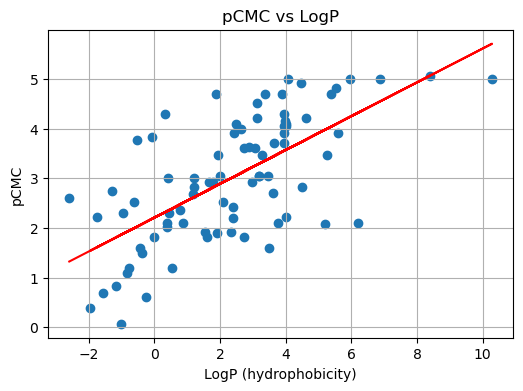

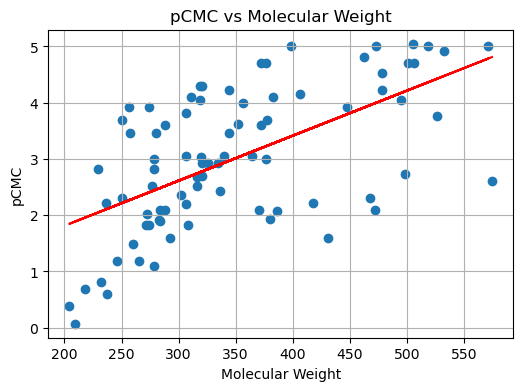

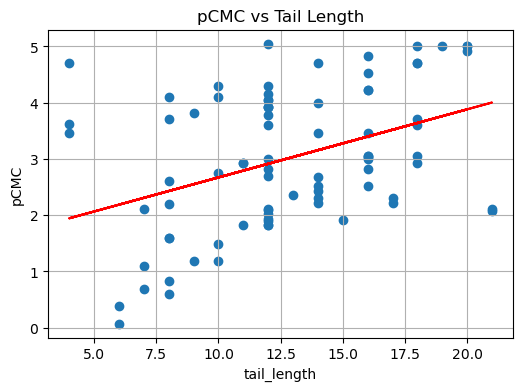

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/processed_surfactants.csv")
df.head()

#pCMC vs. lopP
plt.figure(figsize=(6,4))
plt.scatter(df["MolLogP"], df["pCMC"])

slope, intercept = np.polyfit(df["MolLogP"], df["pCMC"], 1)
plt.plot(df["MolLogP"], slope * df["MolLogP"] + intercept, 'r-')

plt.xlabel("LogP (hydrophobicity)")
plt.ylabel("pCMC")
plt.title("pCMC vs LogP")
plt.grid(True)

plt.show()

#pCMC vs. MW
plt.figure(figsize=(6,4))
plt.scatter(df["MolWt"], df["pCMC"])

slope, intercept = np.polyfit(df["MolWt"], df["pCMC"], 1)
plt.plot(df["MolWt"], slope * df["MolWt"] + intercept, 'r-')

plt.xlabel("Molecular Weight")
plt.ylabel("pCMC")
plt.title("pCMC vs Molecular Weight")
plt.grid(True)

plt.show()

#pCMC vs. alkyl chain length
plt.figure(figsize=(6,4))
plt.scatter(df["tail_length"], df["pCMC"])

slope, intercept = np.polyfit(df["tail_length"], df["pCMC"], 1)
plt.plot(df["tail_length"], slope * df["tail_length"] + intercept, 'r-')

plt.xlabel("tail_length")
plt.ylabel("pCMC")
plt.title("pCMC vs Tail Length")
plt.grid(True)

plt.show()